<a href="https://colab.research.google.com/github/matti410/Trading-System-Pipeline-ML/blob/main/TS-Pipeline-ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q TA-Lib==0.8.1 backtesting==0.6.6   # versioni bloccate: cambiarle solo insieme al notebook di collaudo

In [2]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import sys
from pathlib import Path
from google.colab import userdata
import shutil
# Salva il token una volta in Colab: icona chiave a sinistra → "Secrets" → aggiungi GITHUB_TOKEN
# Assicurati che il nome del secret sia 'GITHUB_TOKEN' (o quello che preferisci) e non il token stesso.
GITHUB_TOKEN = userdata.get('GITHUB_TOKEN')

REPO_DIR = Path('/content/Trading-System-Pipeline-ML')
if REPO_DIR.exists():
    shutil.rmtree(REPO_DIR)  # ripulisce il tentativo fallito precedente

!git clone https://{GITHUB_TOKEN}@github.com/matti410/Trading-System-Pipeline-ML.git

%cd Trading-System-Pipeline-ML

PROJECT_ROOT = Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

Cloning into 'Trading-System-Pipeline-ML'...
remote: Enumerating objects: 53, done.
remote: Counting objects: 100% (53/53), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 53 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (53/53), 2.57 MiB | 3.61 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/Trading-System-Pipeline-ML


In [3]:
import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import re
import sys
import time
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import datetime as dt
"""
from mt5_interaction import start_mt5, set_query_timeframe, retrieve_candlestick_data_range
import pytz
import MetaTrader5 as mt5
"""
import entry_long, entry_short
import engine as eng
from engine.indicatori import aggiungi_indicatori
import engine.event_study
import filter_conditions
from target import costruisci_target

print('import ok')

import ok


In [4]:
"""
MT5_username='xxx'
MT5_password='xxx'
MT5_server='ICMarketsEU-Demo'
MT5_path=r"C:\Program Files\MetaTrader 5 IC Markets EU\terminal64.exe"

start_mt5(MT5_username, MT5_password, MT5_server, MT5_path)

start_time_utc = dt.datetime(2020, 1, 1, 23)
fmt = '%Y-%m-%d %H:%M:%S'
tz = pytz.timezone('Europe/Rome')
finish_time_utc = dt.datetime.now() + relativedelta(hours=4)

symbol = "EURUSD"
timeframe = 'M15'
horizon=15

df_raw = retrieve_candlestick_data_range(start_time_utc, finish_time_utc, symbol, timeframe=timeframe, dataframe=True).iloc[:-1]

df_raw.head(3)
"""
from engine.broker_tz_diagnostic import to_utc_index

symbol    = "EURUSD"
timeframe = 'M15'

df_raw = pd.read_csv(f'{symbol}_M15.csv', index_col='Date')
df_raw = to_utc_index(df_raw, "A_US_DST (NY+7h)", on_dst_gap="drop")

print(f"{symbol} {timeframe} — {len(df_raw):,} barre  ·  da {df_raw.index[0]}  a  {df_raw.index[-1]}")
df_raw.tail(3)

EURUSD M15 — 167,219 barre  ·  da 2020-01-01 22:00:00+00:00  a  2026-09-18 20:30:00+00:00


,Open,High,Low,Close,Volume,spread
Date,,,,,,
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0


### Features Engineering

In [5]:
df = aggiungi_indicatori(df_raw)

In [6]:
# CONDIZIONI DI INGRESSO LONG/SHORT
df = entry_short.aggiungi_trigger_short(df)
df = entry_long.aggiungi_trigger_long(df)

# CONDIZIONI DI FILTRO
for nome, (funzione, direction, pair) in filter_conditions.FILTRI.items():
    df[nome] = funzione(df)

df.dropna(inplace=True)

# Taglio del riscaldamento: nelle prime barre alcune condizioni valgono False
# solo perche' manca storia (un confronto con NaN da' False, non NaN, quindi
# dropna non le toglie). La finestra piu' lunga del catalogo e' E7 (percentile
# su 2000 barre). Se aggiungi una condizione con finestra piu' lunga, alza questo numero.
RISCALDAMENTO = 2100
df = df.iloc[RISCALDAMENTO:]
print(f"Dopo il riscaldamento: {len(df):,} barre, da {df.index[0]}")
df.tail(5)

Dopo il riscaldamento: 165,023 barre, da 2020-02-03 19:00:00+00:00


,Open,High,Low,Close,Volume,spread,rsi,macd,macd_signal,macd_hist,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,0,65.639325,0.000440,0.000315,0.000125,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,0,64.994395,0.000444,0.000341,0.000103,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,0,66.415834,0.000452,0.000363,0.000089,...,True,False,True,False,False,False,True,False,True,False
2026-09-18 20:15:00+00:00,1.14876,1.14890,1.14868,1.14880,262,0,66.898341,0.000456,0.000382,0.000074,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:30:00+00:00,1.14880,1.14885,1.14846,1.14857,182,0,61.432928,0.000436,0.000392,0.000043,...,True,False,True,False,False,False,True,False,False,False


### Andamento del prezzo dopo il trigger

##### IS - OOS Split

In [7]:
df_is = df.iloc[:round(len(df)*0.8)]
df_oos = df.iloc[round(len(df)*0.8):]

In [8]:
entry_long.registra_trigger_long()
entry_short.registra_trigger_short()

[registra_trigger_long] 26 entry long registrate (0 gia' presenti).
[registra_trigger_short] 26 entry short registrate (0 gia' presenti).


In [9]:
H = 25
MIN_TRADES = 200

pip = 0.0001 unita' di prezzo  (prezzo medio 1.11)
4 entry scartate sotto min_trades=200
  barra   3/25
  barra   6/25
  barra   9/25
  barra  12/25
  barra  15/25
  barra  18/25
  barra  21/25
  barra  24/25
  barra  25/25

48 entry · orizzonte 25 barre · 175,247 trigger misurati
soglia di rumore per 48 entry × picco su 25 barre (famiglia 5%): |volte_incertezza| > 3.90  —  entry oltre: 0. Conta solo le prove di questa chiamata, e' un pavimento


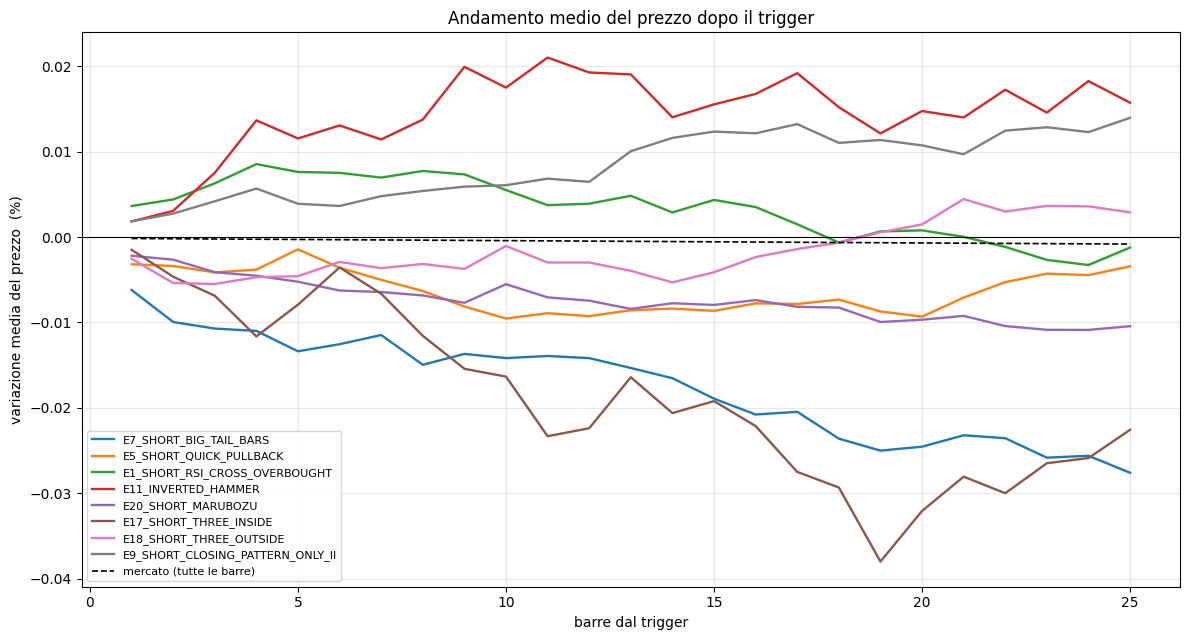

In [10]:
entry_candidate = [n for n in eng.registry.list_entries()]
ev = eng.event_study.run_event_study(df_is, entry_names=entry_candidate, horizon=H, min_trades=MIN_TRADES)
ev.plot()

#### LONG side

In [11]:
l1 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
l1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
3,E11_INVERTED_HAMMER,2.313125,0.021008,2.701351,False
10,E1_RSI_CROSS_OVERSOLD,1.732702,0.015706,1.972294,False
26,E7_BIG_TAIL_BARS,1.276890,0.011531,1.288670,False
24,E18_THREE_OUTSIDE,1.166336,0.010629,1.385477,False
32,E6_BACK_IN_STYLE,0.860244,0.007782,1.110424,False
28,E14_HARAMI_CROSS,0.841387,0.007599,1.193692,False


In [12]:
l2 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                          'picco_pct', 'volte_incertezza',
                                          'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)
l2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
5,E17_SHORT_THREE_INSIDE,-4.177133,-0.037976,-2.372705,False
0,E7_SHORT_BIG_TAIL_BARS,-3.047526,-0.027587,-2.987233,False
21,E16_SHORT_EVENING_STAR,-1.655397,-0.015022,-1.471398,False
18,E6_SHORT_BACK_IN_STYLE,-1.486623,-0.013440,-1.650280,False
4,E20_SHORT_MARUBOZU,-1.203756,-0.010870,-2.487167,False
45,E11_SHORT_SHOOTING_STAR_CONFIRMED,-1.153776,-0.010473,-0.727566,False


#### SHORT side

In [13]:
s1 = ev.sintesi[ev.sintesi['direction'] == -1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=False).head(6)
s1

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
7,E9_SHORT_CLOSING_PATTERN_ONLY_II,1.543825,0.013950,2.258658,False
27,E4_SHORT_EMA_CROSS_DOWN,1.082217,0.009793,1.237565,False
2,E1_SHORT_RSI_CROSS_OVERBOUGHT,0.946055,0.008538,2.783721,False
12,E3_SHORT_INTRABAR_STRENGTH_FADE,0.410163,0.003706,1.870053,False
46,E10_SHORT_HANGING_MAN,0.309685,0.002793,0.633767,False
14,E2_SHORT_ZLEMA_CROSS_DOWN,-0.210925,-0.001906,-1.809164,False


In [14]:
s2 = ev.sintesi[ev.sintesi['direction'] == 1][['candidato', 'picco_pips',
                                           'picco_pct', 'volte_incertezza',
                                           'oltre_rumore']].sort_values('picco_pips', ascending=True).head(6)

s2

,candidato,picco_pips,picco_pct,volte_incertezza,oltre_rumore
22,E17_THREE_INSIDE,-1.944269,-0.017650,-1.466669,False
8,E4_EMA_CROSS_UP,-1.462301,-0.013231,-2.232531,False
47,E16_MORNING_STAR,-1.074913,-0.009789,-0.525162,False
9,E5_QUICK_PULLBACK,-0.958929,-0.008670,-2.015190,False
34,E14_HARAMI_CROSS_CONFIRMED,-0.853003,-0.007694,-1.076027,False
19,E8_CLOSING_PATTERN_ONLY,-0.568189,-0.005132,-1.592568,False


### LONG Dataframe

In [15]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_long_selected_feat  = l1.iloc[:2,0].to_list() + s1.iloc[:2,0].to_list()

df_LONG = df[colonne_ohlcv + entry_long_selected_feat + colonne_eventi]
df_LONG

,Open,High,Low,Close,Volume,E11_INVERTED_HAMMER,E1_RSI_CROSS_OVERSOLD,E9_SHORT_CLOSING_PATTERN_ONLY_II,E4_SHORT_EMA_CROSS_DOWN,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-03 19:00:00+00:00,1.10614,1.10630,1.10614,1.10622,274,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:15:00+00:00,1.10622,1.10634,1.10612,1.10634,175,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:30:00+00:00,1.10634,1.10646,1.10610,1.10640,209,False,False,False,False,False,...,True,False,True,False,True,False,False,True,True,False
2020-02-03 19:45:00+00:00,1.10640,1.10654,1.10616,1.10635,387,False,False,False,False,False,...,False,True,True,False,True,False,False,True,True,False
2020-02-03 20:00:00+00:00,1.10635,1.10640,1.10610,1.10614,251,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,True,False,True,False,False,False,True,False,True,False


#### SHORT Dataframe

In [16]:
pattern = re.compile(r'^[F]\d+_')
colonne_eventi = [c for c in df.columns if pattern.match(c)]
colonne_ohlcv = ['Open', 'High', 'Low', 'Close', 'Volume']
entry_short_selected_feat = l2.iloc[:2,0].to_list() + s2.iloc[:2,0].to_list()

df_SHORT = df[colonne_ohlcv + entry_short_selected_feat + colonne_eventi]
df_SHORT

,Open,High,Low,Close,Volume,E17_SHORT_THREE_INSIDE,E7_SHORT_BIG_TAIL_BARS,E17_THREE_INSIDE,E4_EMA_CROSS_UP,F1_ADX_ABOVE,...,F8_UPTREND_CONTEXT,F9_DOWNTREND_CONTEXT,F10_TREND_CONVICTION_UP,F11_TREND_CONVICTION_DOWN,F12_EXTENDED_UP,F13_EXTENDED_DOWN,F16_PRICE_ABOVE_VWAP,F17_PRICE_BELOW_VWAP,F18_HIGH_NEAR_RANGE_TOP,F19_LOW_NEAR_RANGE_BOTTOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-02-03 19:00:00+00:00,1.10614,1.10630,1.10614,1.10622,274,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:15:00+00:00,1.10622,1.10634,1.10612,1.10634,175,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
2020-02-03 19:30:00+00:00,1.10634,1.10646,1.10610,1.10640,209,False,False,False,False,False,...,True,False,True,False,True,False,False,True,True,False
2020-02-03 19:45:00+00:00,1.10640,1.10654,1.10616,1.10635,387,False,False,False,False,False,...,False,True,True,False,True,False,False,True,True,False
2020-02-03 20:00:00+00:00,1.10635,1.10640,1.10610,1.10614,251,False,False,False,False,False,...,False,True,True,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-18 19:30:00+00:00,1.14879,1.14885,1.14864,1.14867,402,False,False,False,False,True,...,True,False,True,False,True,False,True,False,True,False
2026-09-18 19:45:00+00:00,1.14867,1.14879,1.14857,1.14864,457,False,False,False,False,True,...,True,False,True,False,False,False,True,False,False,False
2026-09-18 20:00:00+00:00,1.14865,1.14890,1.14858,1.14876,454,False,False,False,False,True,...,True,False,True,False,False,False,True,False,True,False


### Costruzione TARGET (LONG / SHORT)

Per ogni trigger calcola l'esito reale: ingresso all'Open della barra successiva, uscita al Close dopo H barre (stesso orizzonte dell'event study). TARGET=1 se il rendimento supera la soglia costi, 0 altrimenti. Righe senza trigger non compaiono — il modello vedrà solo occorrenze reali, mai "rumore".

**Come leggere l'output:** il numero di righe è quanti trigger sono utilizzabili per l'addestramento di ciascun lato; la % di classe 1 dice quanto è bilanciato il problema. Se una delle due % è vicina a 0% o 100%, il modello non ha nulla da imparare — fermati e segnalamelo prima di proseguire.

**Prossimo passo:** se i numeri sono ragionevoli, procediamo con lo split IS/OOS + embargo sui due target.

In [17]:
TARGET_LONG = costruisci_target(df_LONG, entry_long_selected_feat, direction=1, horizon=H)
TARGET_SHORT = costruisci_target(df_SHORT, entry_short_selected_feat, direction=-1, horizon=H)

print("LONG  — righe:", len(TARGET_LONG), " classe 1:", f"{TARGET_LONG.mean():.1%}")
print("SHORT — righe:", len(TARGET_SHORT), " classe 1:", f"{TARGET_SHORT.mean():.1%}")

LONG  — righe: 6790  classe 1: 48.5%
SHORT — righe: 3426  classe 1: 48.1%
